# Train LightGB

### Imports

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import datetime, timedelta
import lightgbm as lgb
import joblib
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from typing import cast
import numpy.typing as npt

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Required to avoid import bugs
root_path = Path.cwd().parent.parent
sys.path.append(str(root_path))

import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
    stream=sys.stdout # Indispensable pour voir les logs sous la cellule
)

# personalized imports
from scripts.data_preparation.get_main import main_query_db
from scripts.data_preparation.preprocessed import main_preprocessed
from scripts.data_preparation.utils.progress_bar import TqdmCallback

### Global variables

In [34]:
root = Path(os.getcwd()).parent.parent
DATA_FOLDER_PATH = os.path.join(root, "data")

DATASET_PATH_PAX = os.path.join(DATA_FOLDER_PATH, "main_preprocessed.csv")
DATASET_PATH_PHMR = os.path.join(DATA_FOLDER_PATH, "main_preprocessed_PHMR.csv")

MODEL_FOLDER_PATH = os.path.join(root, "models")
MODEL_FILENAME = os.path.join(MODEL_FOLDER_PATH, "lgbm_regressor.pkl")
MODEL_FILENAME_PHMR = os.path.join(MODEL_FOLDER_PATH, "lgbm_regressor_PHMR.pkl")

TARGET = ["NbPaxTotal", "FarmsNbPaxPHMR"]

# Today & tomorrow
now = datetime.now()
today = pd.Timestamp(now.date())
yesterday =  pd.Timestamp(today - timedelta(days=1))
two_days_ago = pd.Timestamp(yesterday - timedelta(days=1))
tomorrow = pd.Timestamp(today + timedelta(days=1))
two_days_later = pd.Timestamp(tomorrow + timedelta(days=1))

LIMIT_DATE_TRAIN = two_days_ago
LIMIT_DATE_VALID = today
LIMIT_DATE_TEST = two_days_later


# LIMIT_DATE_TRAIN = pd.Timestamp("2026-03-27")
# LIMIT_DATE_VALID = pd.Timestamp("2026-03-28")
# LIMIT_DATE_TEST = pd.Timestamp("2026-03-30")


PREDICTIONS_FILENAME = os.path.join(DATA_FOLDER_PATH, f"prediction_{LIMIT_DATE_VALID.strftime('%Y-%m-%d')}.csv")

### Load and prepare data

In [36]:
# Load the preprocessed data - or build the needed df.
if os.path.exists(DATASET_PATH_PAX) and os.path.exists(DATASET_PATH_PHMR) : 
    logging.info('Loading preprocessed file ...')
    df = pd.read_csv(DATASET_PATH_PAX, encoding='utf-8')
    df_PHMR = pd.read_csv(DATASET_PATH_PHMR, encoding='utf-8')
else:
    ### Full pipeline
    # Query the data
    # Using BigQuery.
    logging.info("Querying ...")
    #main_query_db()
    logging.info("Preprocessing ...")
    df, df_PHMR = main_preprocessed(with_holidays=False)

2026-04-01 18:27:37,203 - INFO - Querying ...
2026-04-01 18:27:37,203 - INFO - Preprocessing ...
Data split - PHMR management


KeyboardInterrupt: 

#### Data splitting

In [ ]:
### PAX
df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'])

train_df = df[df['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()
test_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (df['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()

print(f"Train set: {len(train_df)} rows / From {train_df['LTScheduledDatetime'].min()} to {train_df['LTScheduledDatetime'].max()}")
print(f"Valid set: {len(valid_df)} rows / From {valid_df['LTScheduledDatetime'].min()} to {valid_df['LTScheduledDatetime'].max()}")
print(f"Test set: {len(test_df)} rows / From {test_df['LTScheduledDatetime'].min()} to {test_df['LTScheduledDatetime'].max()}\n")

### PHMR
df_PHMR['LTScheduledDatetime'] = pd.to_datetime(df_PHMR['LTScheduledDatetime'])

train_df_PHMR = df_PHMR[df_PHMR['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df_PHMR = df_PHMR[(df_PHMR['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df_PHMR['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()
test_df_PHMR = df_PHMR[(df_PHMR['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (df_PHMR['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()

print(f"Train set PHMR: {len(train_df_PHMR)} rows / From {train_df_PHMR['LTScheduledDatetime'].min()} to {train_df_PHMR['LTScheduledDatetime'].max()}")
print(f"Valid set PHMR: {len(valid_df_PHMR)} rows / From {valid_df_PHMR['LTScheduledDatetime'].min()} to {valid_df_PHMR['LTScheduledDatetime'].max()}")
print(f"Test set PHMR: {len(test_df_PHMR)} rows / From {test_df_PHMR['LTScheduledDatetime'].min()} to {test_df_PHMR['LTScheduledDatetime'].max()}")


Train set: 309665 rows / From 2023-01-01 00:05:00 to 2026-03-29 23:50:00
Valid set: 560 rows / From 2026-03-30 00:05:00 to 2026-03-31 23:55:00
Test set: 587 rows / From 2026-04-01 00:25:00 to 2026-04-02 23:55:00

Train set PHMR: 309665 rows / From 2023-01-01 00:05:00 to 2026-03-29 23:50:00
Valid set PHMR: 560 rows / From 2026-03-30 00:05:00 to 2026-03-31 23:55:00
Test set PHMR: 587 rows / From 2026-04-01 00:25:00 to 2026-04-02 23:55:00


#### Last preprocess

In [ ]:
### PAX
# re-conversion in str mandatory to be able to train the model. Note that keep this variable is mandatory.
train_df['LTScheduledDatetime'] = train_df['LTScheduledDatetime'].astype(str)
valid_df['LTScheduledDatetime'] = valid_df['LTScheduledDatetime'].astype(str)
test_df['LTScheduledDatetime'] = test_df['LTScheduledDatetime'].astype(str)

# Slice X, y
X_train = train_df.drop(columns=[TARGET[0]])
y_train = train_df[TARGET[0]]
X_valid = valid_df.drop(columns=[TARGET[0]])
y_valid = valid_df[TARGET[0]]
X_test = test_df.drop(columns=[TARGET[0]])

# Convert to categorical the needed features.
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')
    X_test[col] = X_test[col].astype('category')


print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_valid: {X_valid.shape}")
print(f"Shape X_test: {X_test.shape}\n")

### PHMR
# re-conversion in str mandatory to be able to train the model. Note that keep this variable is mandatory.
train_df_PHMR['LTScheduledDatetime'] = train_df_PHMR['LTScheduledDatetime'].astype(str)
valid_df_PHMR['LTScheduledDatetime'] = valid_df_PHMR['LTScheduledDatetime'].astype(str)
test_df_PHMR['LTScheduledDatetime'] = test_df_PHMR['LTScheduledDatetime'].astype(str)

# Slice X, y
X_train_PHMR = train_df_PHMR.drop(columns=[TARGET[1]])
y_train_PHMR = train_df_PHMR[TARGET[1]]
X_valid_PHMR = valid_df_PHMR.drop(columns=[TARGET[1]])
y_valid_PHMR = valid_df_PHMR[TARGET[1]]
X_test_PHMR = test_df_PHMR.drop(columns=[TARGET[1]])

# Convert to categorical the needed features.
for col in X_train_PHMR.select_dtypes(include=['object']).columns:
    X_train_PHMR[col] = X_train_PHMR[col].astype('category')
    X_valid_PHMR[col] = X_valid_PHMR[col].astype('category')
    X_test_PHMR[col] = X_test_PHMR[col].astype('category')


print(f"Shape X_train_PHMR: {X_train_PHMR.shape}")
print(f"Shape X_valid_PHMR: {X_valid_PHMR.shape}")
print(f"Shape X_test_PHMR: {X_test_PHMR.shape}")


Shape X_train: (309665, 596)
Shape X_valid: (560, 596)
Shape X_test: (587, 596)

Shape X_train_PHMR: (309665, 30)
Shape X_valid_PHMR: (560, 30)
Shape X_test_PHMR: (587, 30)


### Train or Load the model

#### 1. Pax train

In [ ]:
# Check if there is an existing model.
if os.path.exists(MODEL_FILENAME) :
    model_Pax = joblib.load(MODEL_FILENAME)
    logging.info("Pax model load successfuly.")

else : 
    n_estimators = 10000

    model_Pax = lgb.LGBMRegressor(
        objective="regression",      
        n_estimators=n_estimators,      
        learning_rate=0.01,
        num_leaves=255,               
        min_child_samples=5,
        feature_fraction=0.8,
        random_state=42,
        verbose=-1
    )

    tqdm_callback = TqdmCallback(total=n_estimators)
    try:
        model_Pax.fit(
            X_train, y_train,         
            eval_set=[(X_valid, y_valid)], 
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(100),
                tqdm_callback 
            ]
        )
    finally:
        tqdm_callback.pbar.close()

    joblib.dump(model_Pax, MODEL_FILENAME)

LightGBM training:   0%|          | 1/10000 [00:08<23:53:02,  8.60s/it, mae=59.9541]

Training until validation scores don't improve for 100 rounds


LightGBM training:   5%|▍         | 453/10000 [02:14<38:50,  4.10it/s, mae=23.0409] 

Early stopping, best iteration is:
[353]	valid_0's l1: 23.531	valid_0's l2: 1642.99


LightGBM training:   5%|▍         | 453/10000 [02:15<47:29,  3.35it/s, mae=23.0409]


#### 2. PHMR Train

In [ ]:
# Check if there is an existing model.
if os.path.exists(MODEL_FILENAME_PHMR) :  
    model_PHMR = joblib.load(MODEL_FILENAME_PHMR)
    logging.info("PHMR model load successfuly.")

else : 
    n_estimators = 10000

    model_PHMR = lgb.LGBMRegressor(
        objective="regression",      
        n_estimators=n_estimators,      
        learning_rate=0.01,
        num_leaves=255,               
        min_child_samples=5,
        feature_fraction=0.8,
        random_state=42,
        verbose=-1
    )

    tqdm_callback = TqdmCallback(total=n_estimators)
    try:
        model_PHMR.fit(
            X_train_PHMR, y_train_PHMR,         
            eval_set=[(X_valid_PHMR, y_valid_PHMR)], 
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(100),
                tqdm_callback 
            ]
        )
    finally:
        tqdm_callback.pbar.close()

    joblib.dump(model_PHMR, MODEL_FILENAME_PHMR)

LightGBM training:   0%|          | 12/10000 [00:00<12:42, 13.10it/s, mae=0.8670] 

Training until validation scores don't improve for 100 rounds


LightGBM training:   5%|▌         | 518/10000 [00:11<03:29, 45.26it/s, mae=0.2805]

Early stopping, best iteration is:
[418]	valid_0's l1: 0.285343	valid_0's l2: 1.01809


LightGBM training:   5%|▌         | 518/10000 [00:11<03:31, 44.79it/s, mae=0.2805]


### Prediction and Evaluation

#### Evaluation on the validation dataset

- PAX :

In [ ]:
predictions = model_Pax.predict(X_valid)
preds_array = cast(npt.NDArray[np.float32], predictions)
predictions = np.maximum(0.0, preds_array)

mae = mean_absolute_error(y_valid, predictions)
r2 = r2_score(y_valid, predictions)
rmse = root_mean_squared_error(y_valid, predictions)

print(f"\n── Results for Pax model ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── Results for Pax model ──
   MAE : 23.53 passengers
   R²  : 0.6288
   RMSE : 40.53


- PHMR

In [ ]:
predictions_PHMR = model_PHMR.predict(X_valid_PHMR)
preds_array = cast(npt.NDArray[np.float32], predictions_PHMR)
predictions_PHMR = np.maximum(0.0, preds_array)

mae = mean_absolute_error(y_valid_PHMR, predictions_PHMR)
r2 = r2_score(y_valid_PHMR, predictions_PHMR)
rmse = root_mean_squared_error(y_valid_PHMR, predictions_PHMR)

print(f"\n── Results for PHMR models ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── Results for PHMR models ──
   MAE : 0.29 passengers
   R²  : 0.7618
   RMSE : 1.01


#### Predictions

In [10]:
# predictions
predictions_nb_pax = model_Pax.predict(X_test)
preds_nb_pax_array = cast(npt.NDArray[np.float32], predictions_nb_pax)
predictions_nb_pax = np.maximum(0.0, preds_nb_pax_array)
predictions_nb_pax = np.round(predictions_nb_pax)

predictions_phmr_pax = model_PHMR.predict(X_test_PHMR)
preds_phmr_pax = cast(npt.NDArray[np.float32], predictions_phmr_pax)
predictions_phmr_pax = np.maximum(0.0, preds_phmr_pax)
predictions_phmr_pax = np.round(predictions_phmr_pax)

df_final = X_test[['FlightNumberNormalized', 'LTScheduledDatetime']].copy() 
df_final.loc[:, 'PredNbPaxTotal'] = predictions_nb_pax
df_final.loc[:, 'PredFarmsNbPaxPHMR'] = predictions_phmr_pax

df_final.to_csv(PREDICTIONS_FILENAME, encoding = 'utf-8', index=False)

#### Prediction evaluation

In [11]:
def calculate_all_metrics(df, col_pred, col_reel, col_date):
    """
    Calcule le WAPE et le Ratio de prédiction au global, par jour et par heure.
    """
    # 1. S'assurer que la colonne date est au bon format
    df = df.copy()
    df[col_date] = pd.to_datetime(df[col_date])
    df['Jour'] = df[col_date].dt.date
    df['Heure'] = df[col_date].dt.hour

    # --- MÉTRIQUES TOTALES ---
    total_reel = df[col_reel].sum()
    total_pred = df[col_pred].sum()
    
    total_metrics = {
        'WAPE_Global': np.abs(total_pred - total_reel) / total_reel,
        'Pred_Ratio_Global': (total_pred / total_reel) * 100
    }

    # --- Daily ---
    daily_agg = df.groupby('Jour').agg({col_reel: 'sum', col_pred: 'sum'})
    daily_agg['WAPE'] = np.abs(daily_agg[col_pred] - daily_agg[col_reel]) / daily_agg[col_reel]
    daily_agg['Ratio_Pred'] = (daily_agg[col_pred] / daily_agg[col_reel]) * 100

    # --- Hourly ---
    hourly_agg = df.groupby('Heure').agg({col_reel: 'sum', col_pred: 'sum'})
    hourly_agg['WAPE'] = np.abs(hourly_agg[col_pred] - hourly_agg[col_reel]) / hourly_agg[col_reel]
    hourly_agg['Ratio_Pred'] = (hourly_agg[col_pred] / hourly_agg[col_reel]) * 100

    return {
        "Global": total_metrics,
        "Daily": daily_agg.reset_index(),
        "Hourly": hourly_agg.reset_index()
    }



In [12]:
### Build the DataFrame used for predictions evaluation.
RAW_FILENAME = os.path.join(DATA_FOLDER_PATH, "main.csv")

# Load the raw data
raw_data = pd.read_csv(RAW_FILENAME, encoding='utf-8')
raw_data['LTScheduledDatetime'] = pd.to_datetime(raw_data['LTScheduledDatetime'])
raw_data_test = raw_data[(raw_data['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (raw_data['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()
raw_data_test = raw_data_test[["FlightNumberNormalized", "LTScheduledDatetime", "NbPaxTotal", "FarmsNbPaxPHMR"]].copy()

df_final['LTScheduledDatetime'] = pd.to_datetime(df_final['LTScheduledDatetime'])

df_merge = pd.merge(left=raw_data_test, right=df_final, on=["FlightNumberNormalized", "LTScheduledDatetime"], how="left")


In [ ]:
# --- Evaluation ---  
# /!\ To run only if we have the labels for the test set (for evaluation...)
results = calculate_all_metrics(df_merge, 'PredNbPaxTotal', 'NbPaxTotal', 'LTScheduledDatetime')
results_PHMR = calculate_all_metrics(df_merge, 'PredFarmsNbPaxPHMR', 'FarmsNbPaxPHMR', 'LTScheduledDatetime')

print("--- Results NbPaxTotal ---")
print(f"WAPE Global: {results['Global']['WAPE_Global']:.2%} - Ratio Global: {results['Global']['Pred_Ratio_Global']:.2f}")
print(results['Daily'].head())
print('\n')
print(results['Hourly'].head())
print('\n')


print("--- Results FarmsNbPaxPHMR ---")
print(f"WAPE Global: {results_PHMR['Global']['WAPE_Global']:.2%} - Ratio Global: {results_PHMR['Global']['Pred_Ratio_Global']:.2f}")
print(results_PHMR['Daily'].head())
print('\n')
print(results_PHMR['Hourly'].head())        # Not relevant.
print('\n')


--- Results NbPaxTotal ---
WAPE Global: 18701.31% - Ratio Global: 18801.31
         Jour  NbPaxTotal  PredNbPaxTotal       WAPE   Ratio_Pred
0  2026-04-01       305.0         26190.0  84.868852  8586.885246
1  2026-04-02         0.0         31154.0        inf          inf


   Heure  NbPaxTotal  PredNbPaxTotal      WAPE  Ratio_Pred
0      0       131.0           702.0  4.358779  535.877863
1      1       174.0           280.0  0.609195  160.919540
2      4         0.0             6.0       inf         inf
3      5         0.0           191.0       inf         inf
4      6         0.0          2651.0       inf         inf


--- Results FarmsNbPaxPHMR ---
WAPE Global: 48.28% - Ratio Global: 148.28
         Jour  FarmsNbPaxPHMR  PredFarmsNbPaxPHMR      WAPE  Ratio_Pred
0  2026-04-01           121.0               107.0  0.115702   88.429752
1  2026-04-02            82.0               194.0  1.365854  236.585366


   Heure  FarmsNbPaxPHMR  PredFarmsNbPaxPHMR      WAPE  Ratio_Pred
0      0  

## Analysis

### NbPaxTotal

#### 1. Feature importance

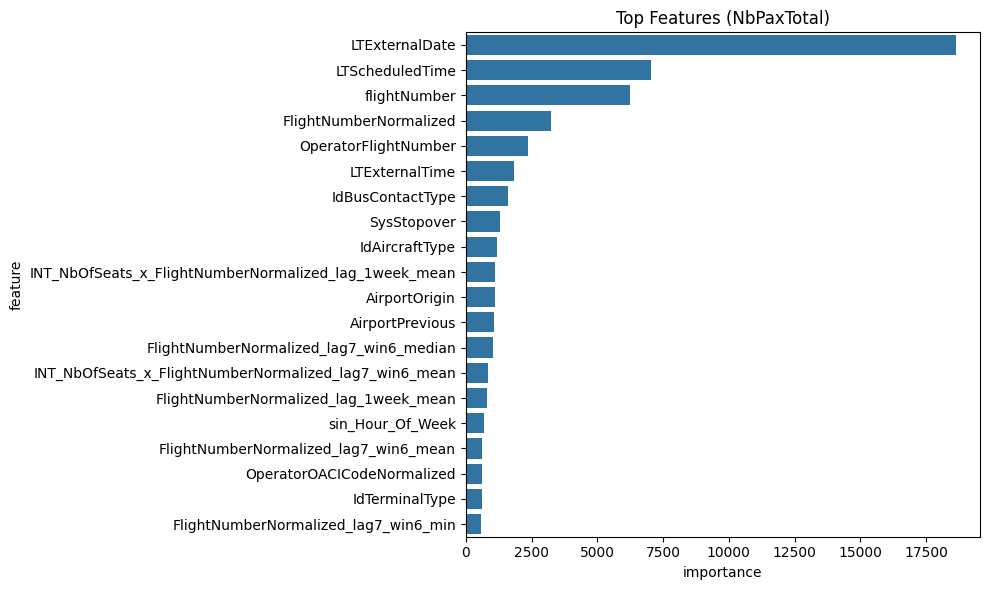

In [14]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_Pax.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv(os.path.join(DATA_FOLDER_PATH, "features_importances_Pax.csv"), index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (NbPaxTotal)")
plt.tight_layout()
plt.show()

#### 2. Prediction VS Reality

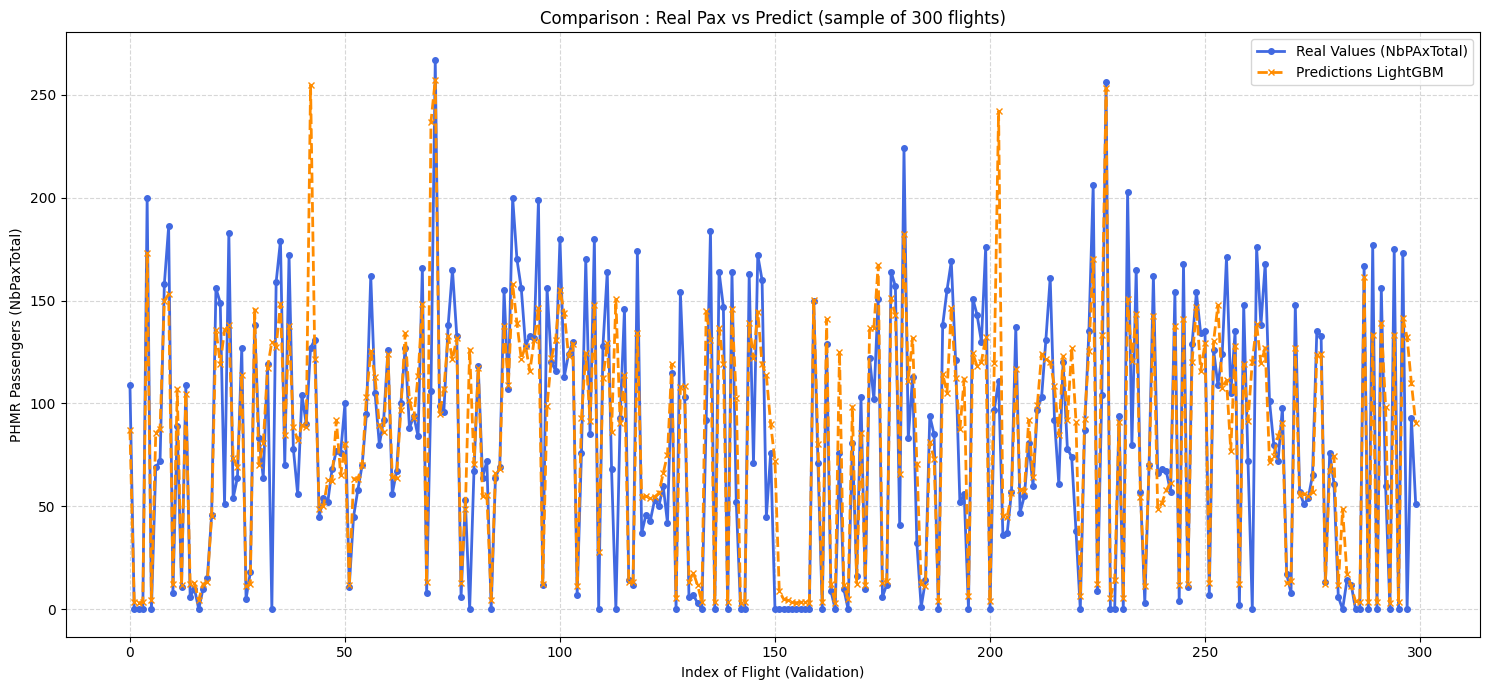

In [15]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid.values[:n_sample], label='Real Values (NbPAxTotal)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions[:n_sample], label='Predictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparison : Real Pax vs Predict (sample of {n_sample} flights)')
plt.ylabel('PHMR Passengers (NbPaxTotal)')
plt.xlabel('Index of Flight (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. TOP 10 Errors

In [16]:
analysis_df = valid_df.copy()
analysis_df['Predicted_NbPax'] = predictions
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET[0]] - analysis_df['Predicted_NbPax'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

def highlight_errors(df):
    
    # Columns to show
    columns = ["FlightNumberNormalized", "LTExternalDatetime", TARGET[0], 
               "Predicted_NbPax", "NbOfSeats", "Abs_Error"]
    
    # Rounding values
    display_df = df[columns].copy().head(10)
    display_df['Predicted_NbPax'] = display_df['Predicted_NbPax'].round(1)
    display_df['Abs_Error'] = display_df['Abs_Error'].round(1)
    
    # Style
    return display_df.style\
        .background_gradient(subset=['Abs_Error'], cmap='Reds')\
        .background_gradient(subset=[TARGET[0]], cmap='Blues')\
        .format({'LTScheduledDatetime': lambda x: x.strftime('%d/%m %H:%M')})\
        .set_caption("TOP 10 ERRORS")

highlight_errors(top_errors)

,FlightNumberNormalized,LTExternalDatetime,NbPaxTotal,Predicted_NbPax,NbOfSeats,Abs_Error
330527,EJU04478,2026-03-30 12:45:00,0.000000,164.800000,186.000000,164.800000
330537,EJU04400,2026-03-30 15:10:00,0.000000,163.200000,186.000000,163.200000
330638,EJU04482,2026-03-31 14:25:00,0.000000,161.900000,186.000000,161.900000
330585,EJU04426,2026-03-30 23:40:00,0.000000,161.300000,186.000000,161.300000
330636,VLG01221,2026-03-31 13:55:00,0.000000,160.500000,180.000000,160.500000
346576,VOE02656,2026-03-31 16:50:00,0.000000,160.100000,180.000000,160.100000
330507,VLG01221,2026-03-30 10:10:00,0.000000,156.700000,180.000000,156.700000
164223,VOE02085,2026-03-31 23:50:00,0.000000,154.500000,180.000000,154.500000
330610,EJU06813,2026-03-31 09:05:00,0.000000,153.000000,186.000000,153.000000
164036,ENT00574,2026-03-30 19:15:00,0.000000,150.600000,189.000000,150.600000


### PHMR

#### 1. Feature importance

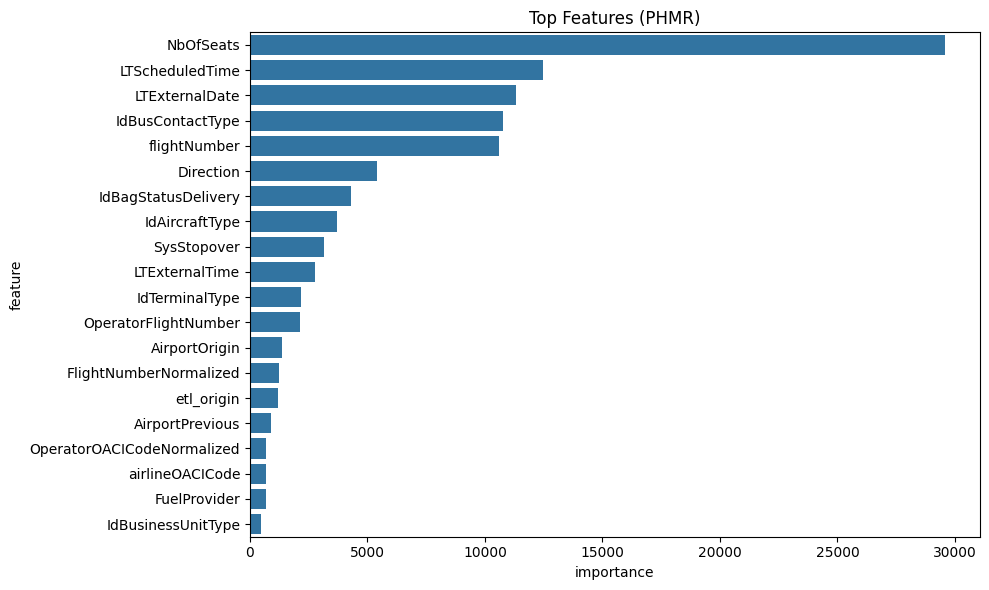

In [17]:
importance = pd.DataFrame({
    "feature": X_train_PHMR.columns,
    "importance": model_PHMR.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv(os.path.join(DATA_FOLDER_PATH, "features_importances_PHMR.csv"), index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (PHMR)")
plt.tight_layout()
plt.show()

#### 2. Prediction VS Reality

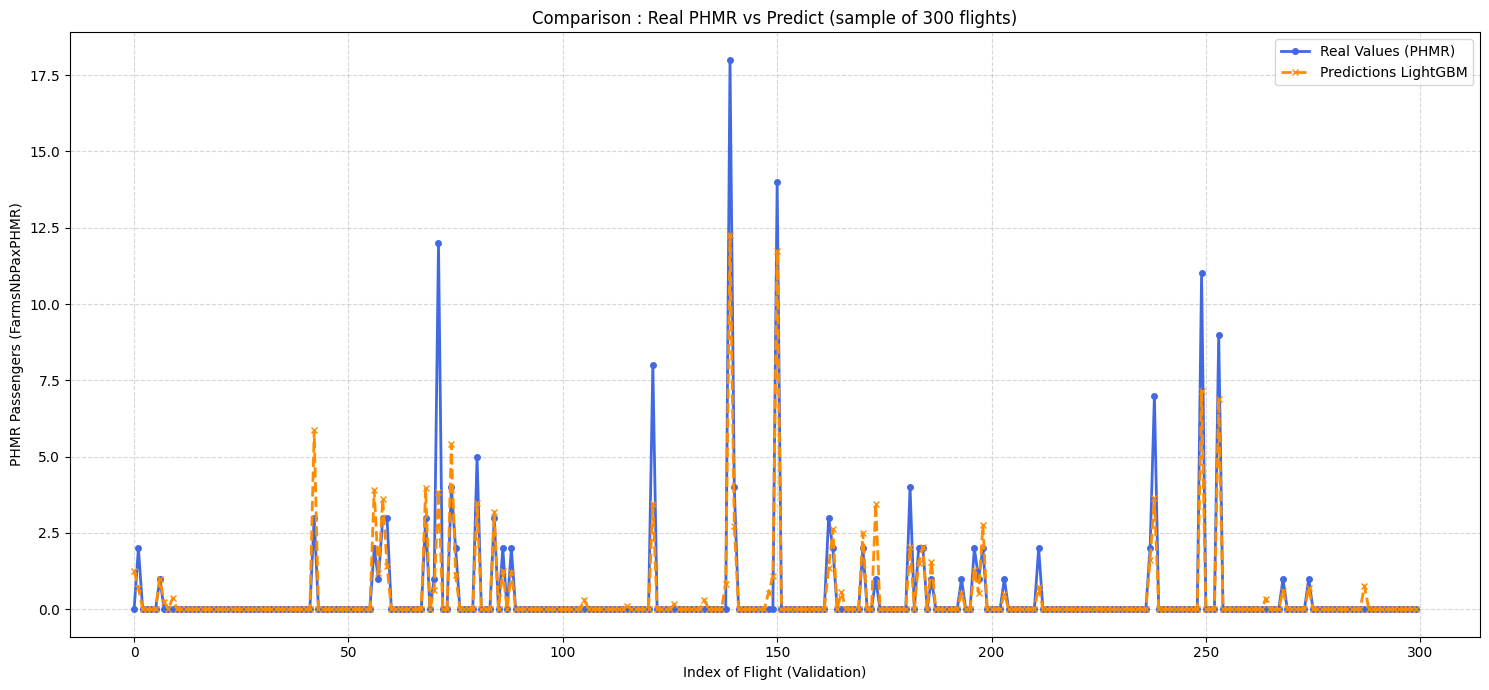

In [18]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid_PHMR.values[:n_sample], label='Real Values (PHMR)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions_PHMR[:n_sample], label='Predictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparison : Real PHMR vs Predict (sample of {n_sample} flights)')
plt.ylabel('PHMR Passengers (FarmsNbPaxPHMR)')
plt.xlabel('Index of Flight (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. TOP 10 Errors

In [19]:
analysis_df = valid_df_PHMR.copy()
analysis_df['Predicted_PHMR'] = predictions_PHMR
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET[1]] - analysis_df['Predicted_PHMR'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

def highlight_errors(df):
    
    # Columns to show
    columns = ["FlightNumberNormalized", "LTExternalDatetime", TARGET[1], 
               "Predicted_PHMR", "NbOfSeats", "Abs_Error"]
    
    # Rounding values
    display_df = df[columns].copy().head(10)
    display_df['Predicted_PHMR'] = display_df['Predicted_PHMR'].round(1)
    display_df['Abs_Error'] = display_df['Abs_Error'].round(1)
    
    # Style
    return display_df.style\
        .background_gradient(subset=['Abs_Error'], cmap='Reds')\
        .background_gradient(subset=[TARGET[1]], cmap='Blues')\
        .format({'LTScheduledDatetime': lambda x: x.strftime('%d/%m %H:%M')})\
        .set_caption("TOP 10 ERRORS")

highlight_errors(top_errors)

,FlightNumberNormalized,LTExternalDatetime,FarmsNbPaxPHMR,Predicted_PHMR,NbOfSeats,Abs_Error
55338,TVF08776,2026-03-30 06:00:00,15.000000,5.500000,189.000000,9.500000
55193,PGT01142,2026-03-30 14:40:00,12.000000,3.500000,239.000000,8.500000
54858,DAH01033,2026-03-31 17:55:00,12.000000,3.800000,144.000000,8.200000
55240,TVF07308,2026-03-30 11:55:00,10.000000,3.700000,189.000000,6.300000
54926,DAH01081,2026-03-31 13:35:00,18.000000,12.300000,162.000000,5.700000
55218,DAH01155,2026-03-30 12:45:00,18.000000,12.700000,148.000000,5.300000
55266,THY01808,2026-03-30 10:25:00,8.000000,2.800000,190.000000,5.200000
54908,PGT01142,2026-03-31 14:40:00,8.000000,3.500000,239.000000,4.500000
55153,DAH01154,2026-03-30 17:15:00,8.000000,3.600000,148.000000,4.400000
55036,TVF08776,2026-03-31 06:35:00,11.000000,7.100000,189.000000,3.900000
